## 1. Setup


In [25]:
import sys
from pathlib import Path

import pandas as pd

# Add src/ to the path so we can import project modules
sys.path.insert(0, str(Path("..").resolve() / "src"))

from face_detector import get_detector

In [26]:
PROCESSED_DIR = Path("..").resolve() / "data" / "processed"

records = []
for label, folder in [(1, "smile"), (0, "non_smile")]:
    folder_path = PROCESSED_DIR / folder
    for img_path in sorted(folder_path.glob("*.jpg")):
        records.append({
            "filename": img_path.name,
            "filepath": str(img_path),
            "label": label,
        })

df = pd.DataFrame(records)

print(f"Total images: {len(df)}")
print(df["label"].value_counts().rename({1: "smile", 0: "non_smile"}))

Total images: 3999
label
smile        2171
non_smile    1828
Name: count, dtype: int64


## 2. Baseline Detection


In [27]:
import cv2
import numpy as np
from tqdm.notebook import tqdm

detector = get_detector()

n_faces_list = []
kps_list = []
det_score_list = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Detecting faces"):
    img = cv2.imread(row["filepath"])
    if img is None:
        n_faces_list.append(0)
        kps_list.append(None)
        det_score_list.append(None)
        continue

    faces = detector.detect(img)
    n_faces_list.append(len(faces))

    if len(faces) == 1:
        kps_list.append(faces[0].kps)
        det_score_list.append(faces[0].det_score)
    else:
        kps_list.append(None)
        det_score_list.append(None)

df_baseline = df.copy()
df_baseline["n_faces"] = n_faces_list
df_baseline["kps"] = kps_list
df_baseline["det_score"] = det_score_list

CACHE_DIR = Path("..").resolve() / "data" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
df_baseline.to_pickle(CACHE_DIR / "detections_baseline.pkl")

print("Saved df_baseline to data/cache/detections_baseline.pkl")
print("\n--- n_faces distribution ---")
dist = df_baseline["n_faces"].value_counts().sort_index()
dist.index = dist.index.map(lambda x: f"{x}+" if x >= 3 else str(x))
print(dist.groupby(level=0).sum() if dist.index.duplicated().any() else dist.to_string())

Detecting faces:   0%|          | 0/3999 [00:00<?, ?it/s]

Saved df_baseline to data/cache/detections_baseline.pkl

--- n_faces distribution ---
n_faces
0        6
1     3965
2       26
3+       2


Images with 0 faces detected: 6


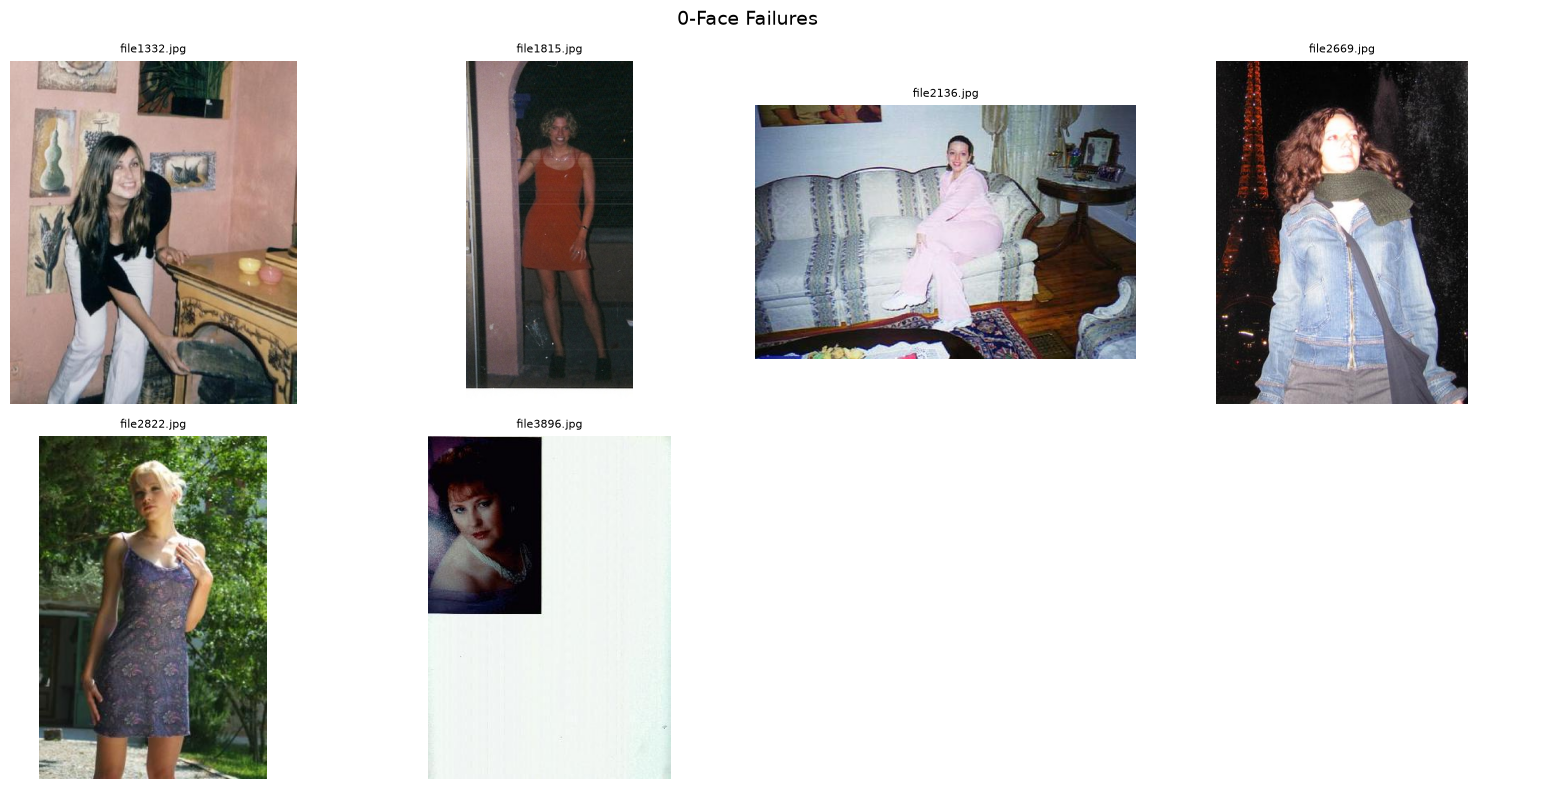

In [28]:
import math
import matplotlib.pyplot as plt

no_faces = df_baseline[df_baseline["n_faces"] == 0]
print(f"Images with 0 faces detected: {len(no_faces)}")

if len(no_faces) > 0:
    n_cols = 4
    n_rows = math.ceil(len(no_faces) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    for i, (_, row) in enumerate(no_faces.iterrows()):
        img = cv2.imread(row["filepath"])
        if img is not None:
            axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[i].set_title(row["filename"], fontsize=8)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("0-Face Failures", fontsize=14)
    plt.tight_layout()
    plt.show()

12 lowest det_score among single-face detections:
    filename  label  det_score
file0488.jpg      1   0.564375
file1852.jpg      1   0.589104
file0625.jpg      1   0.592151
file1570.jpg      1   0.620511
file3838.jpg      0   0.623069
file0196.jpg      1   0.628257
file1946.jpg      1   0.641005
file3127.jpg      0   0.647996
file1944.jpg      1   0.653707
file2511.jpg      0   0.656506
file2607.jpg      0   0.661646
file2524.jpg      0   0.662795


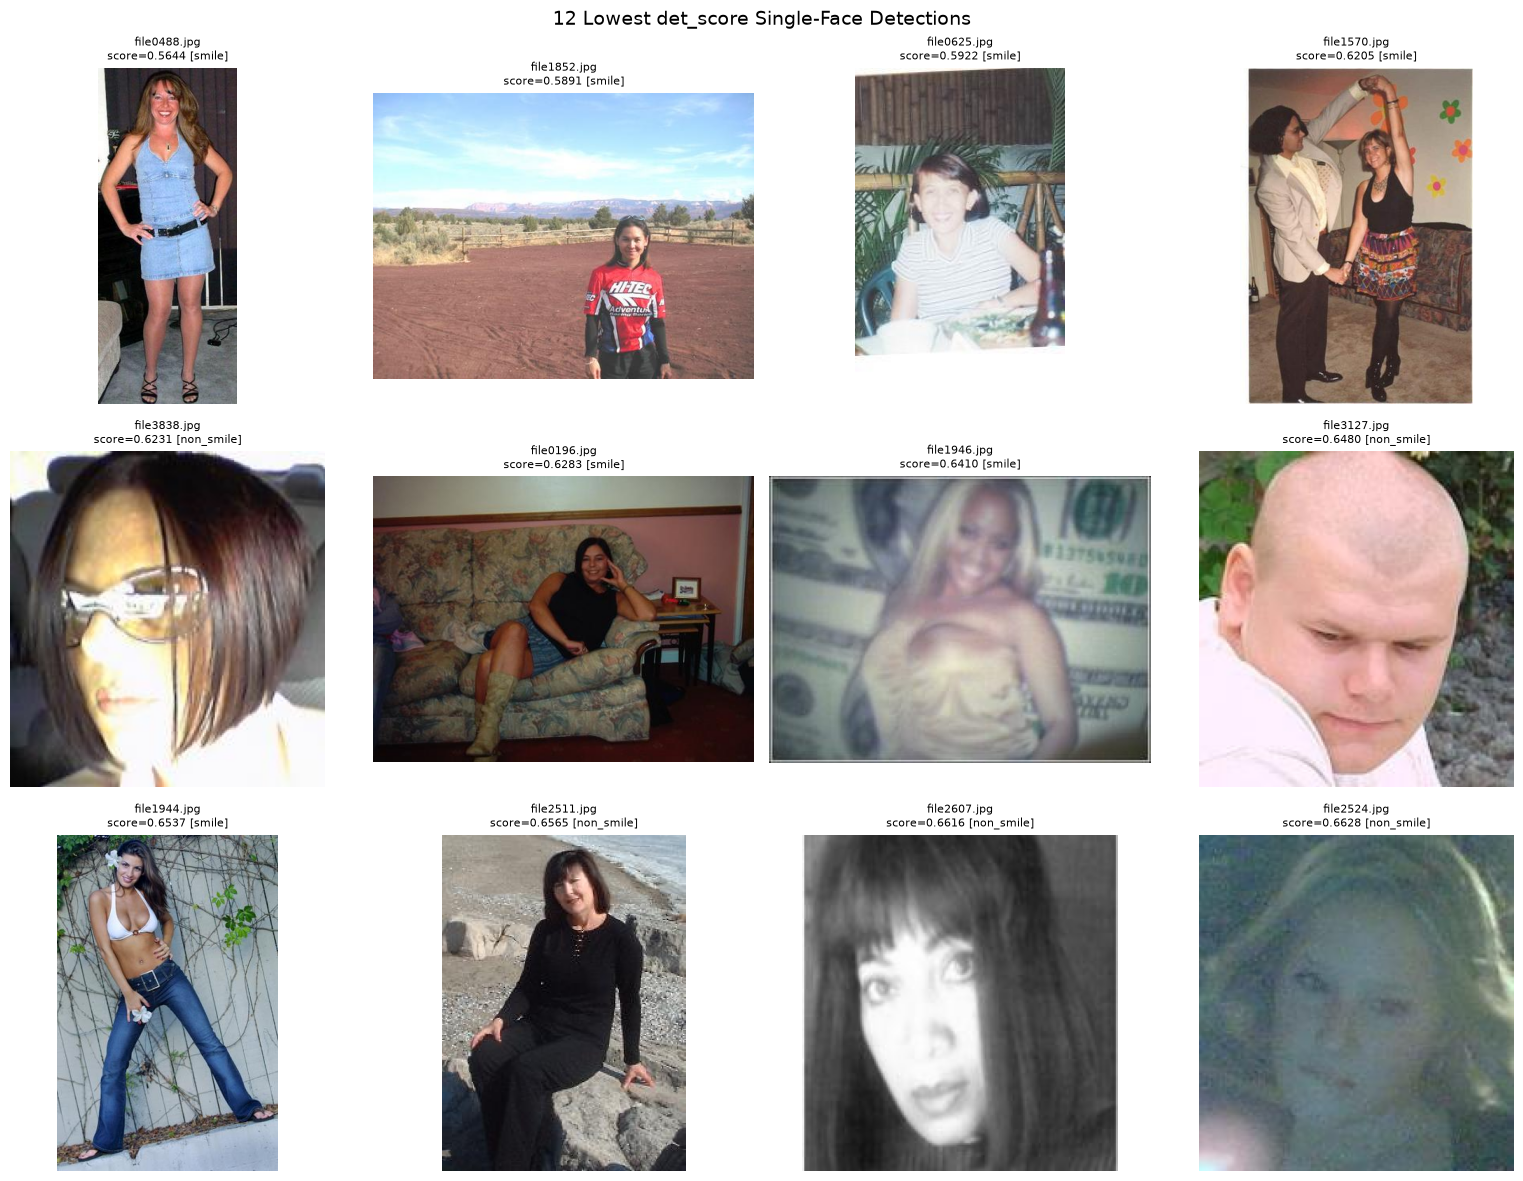

In [29]:
single_face = df_baseline[df_baseline["n_faces"] == 1].copy()
lowest_12 = single_face.sort_values("det_score").head(12)

print("12 lowest det_score among single-face detections:")
print(lowest_12[["filename", "label", "det_score"]].to_string(index=False))

n_cols = 4
n_rows = math.ceil(12 / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

for i, (_, row) in enumerate(lowest_12.iterrows()):
    img = cv2.imread(row["filepath"])
    if img is not None:
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    label_str = "smile" if row["label"] == 1 else "non_smile"
    axes[i].set_title(
        f"{row['filename']}\nscore={row['det_score']:.4f} [{label_str}]",
        fontsize=8,
    )
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("12 Lowest det_score Single-Face Detections", fontsize=14)
plt.tight_layout()
plt.show()

## 3. Fallback & Transform Experiments


In [30]:
from preprocessing import detect_with_fallback

n_faces_fb = []
kps_fb = []
det_score_fb = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Fallback detection"):
    img = cv2.imread(row["filepath"])
    if img is None:
        n_faces_fb.append(0)
        kps_fb.append(None)
        det_score_fb.append(None)
        continue

    faces = detect_with_fallback(detector, img)
    n_faces_fb.append(len(faces))

    if len(faces) == 1:
        kps_fb.append(faces[0].kps)
        det_score_fb.append(faces[0].det_score)
    else:
        kps_fb.append(None)
        det_score_fb.append(None)

df_det = df.copy()
df_det["n_faces"] = n_faces_fb
df_det["kps"] = kps_fb
df_det["det_score"] = det_score_fb

df_det.to_pickle(CACHE_DIR / "detections_raw.pkl")

print("Saved df_det to data/cache/detections_raw.pkl")
print("\n=== Before / After n_faces comparison ===")
before = df_baseline["n_faces"].value_counts().sort_index()
after = df_det["n_faces"].value_counts().sort_index()
comp = pd.DataFrame({"baseline": before, "fallback": after}).fillna(0).astype(int)
comp.index = comp.index.map(lambda x: f"{x}+" if x >= 3 else str(x))
comp = comp.groupby(level=0).sum()
comp["delta"] = comp["fallback"] - comp["baseline"]
print(comp.to_string())

Fallback detection:   0%|          | 0/3999 [00:00<?, ?it/s]

Saved df_det to data/cache/detections_raw.pkl

=== Before / After n_faces comparison ===
         baseline  fallback  delta
n_faces                           
0               6         1     -5
1            3965      3970      5
2              26        26      0
3+              2         2      0


In [31]:
from utils import compute_image_stats

brightness_vals = []
blur_vals = []
for _, row in tqdm(df_det.iterrows(), total=len(df_det), desc="Image quality"):
    img = cv2.imread(row["filepath"])
    s = compute_image_stats(img)
    brightness_vals.append(s["brightness"])
    blur_vals.append(s["blur_val"])

df_det["brightness"] = brightness_vals
df_det["blur"] = blur_vals

bright_5, bright_95 = df_det["brightness"].quantile([0.05, 0.95])
blur_5 = df_det["blur"].quantile(0.05)

hard_dark = df_det[df_det["brightness"] <= bright_5].copy()
hard_bright = df_det[df_det["brightness"] >= bright_95].copy()
hard_blur = df_det[df_det["blur"] <= blur_5].copy()

easy_pool = df_det[
    (df_det["n_faces"] == 1)
    & (df_det["det_score"] > 0.8)
    & (df_det["brightness"] > bright_5) & (df_det["brightness"] < bright_95)
    & (df_det["blur"] > blur_5)
]
easy_control = easy_pool.sample(n=min(30, len(easy_pool)), random_state=42).copy()

print(f"hard_dark  (brightness <= {bright_5:.1f}): {len(hard_dark)} images")
print(f"hard_bright (brightness >= {bright_95:.1f}): {len(hard_bright)} images")
print(f"hard_blur   (blur <= {blur_5:.1f}): {len(hard_blur)} images")
print(f"easy_control (n_faces==1, det>0.8, mid-range): {len(easy_control)} images")


Image quality:   0%|          | 0/3999 [00:00<?, ?it/s]

hard_dark  (brightness <= 61.4): 200 images
hard_bright (brightness >= 166.2): 200 images
hard_blur   (blur <= 61.8): 200 images
easy_control (n_faces==1, det>0.8, mid-range): 30 images


In [32]:
from preprocessing import apply_clahe, apply_gamma, to_grayscale_3ch

transforms = {
    "CLAHE": lambda img: apply_clahe(img),
    "gamma_darken": lambda img: apply_gamma(img, gamma=1.5),
    "gamma_brighten": lambda img: apply_gamma(img, gamma=0.7),
    "grayscale": lambda img: to_grayscale_3ch(img),
}

subsets = {
    "hard_dark": hard_dark,
    "hard_bright": hard_bright,
    "hard_blur": hard_blur,
    "easy_control": easy_control,
}

results = []

for tx_name, tx_fn in transforms.items():
    for sub_name, sub_df in subsets.items():
        for _, row in tqdm(
            sub_df.iterrows(),
            total=len(sub_df),
            desc=f"{tx_name} / {sub_name}",
            leave=False,
        ):
            img = cv2.imread(row["filepath"])
            if img is None:
                continue

            orig_n = int(row["n_faces"])
            orig_score = float(row["det_score"]) if row["det_score"] is not None else None

            transformed = tx_fn(img)
            faces_new = detect_with_fallback(detector, transformed)
            new_n = len(faces_new)
            new_score = faces_new[0].det_score if new_n == 1 else None

            results.append({
                "transform": tx_name,
                "subset": sub_name,
                "filename": row["filename"],
                "orig_n_faces": orig_n,
                "new_n_faces": new_n,
                "orig_det_score": orig_score,
                "new_det_score": new_score,
            })

df_results = pd.DataFrame(results)
print(f"Total transform evaluations: {len(df_results)}")
df_results.head(10)

CLAHE / hard_dark:   0%|          | 0/200 [00:00<?, ?it/s]

CLAHE / hard_bright:   0%|          | 0/200 [00:00<?, ?it/s]

CLAHE / hard_blur:   0%|          | 0/200 [00:00<?, ?it/s]

CLAHE / easy_control:   0%|          | 0/30 [00:00<?, ?it/s]

gamma_darken / hard_dark:   0%|          | 0/200 [00:00<?, ?it/s]

...

grayscale / hard_bright:   0%|          | 0/200 [00:00<?, ?it/s]

grayscale / hard_blur:   0%|          | 0/200 [00:00<?, ?it/s]

grayscale / easy_control:   0%|          | 0/30 [00:00<?, ?it/s]

Total transform evaluations: 2520


,transform,subset,filename,orig_n_faces,new_n_faces,orig_det_score,new_det_score
0,CLAHE,hard_dark,file0004.jpg,1,1,0.883785,0.896672
1,CLAHE,hard_dark,file0010.jpg,1,1,0.846797,0.826850
2,CLAHE,hard_dark,file0026.jpg,1,1,0.797480,0.773648
3,CLAHE,hard_dark,file0048.jpg,1,1,0.801914,0.788812
4,CLAHE,hard_dark,file0070.jpg,1,1,0.811615,0.800369
5,CLAHE,hard_dark,file0093.jpg,1,1,0.898104,0.900797
6,CLAHE,hard_dark,file0102.jpg,1,1,0.835383,0.840817
7,CLAHE,hard_dark,file0116.jpg,1,1,0.855524,0.850121
8,CLAHE,hard_dark,file0134.jpg,1,1,0.772862,0.769562
9,CLAHE,hard_dark,file0139.jpg,1,1,0.892113,0.883571


=== Transform leaderboard ===
     transform  recovered  broken  score
     grayscale          5       0      5
gamma_brighten          4       0      4
  gamma_darken          1       0      1
         CLAHE          0       0      0


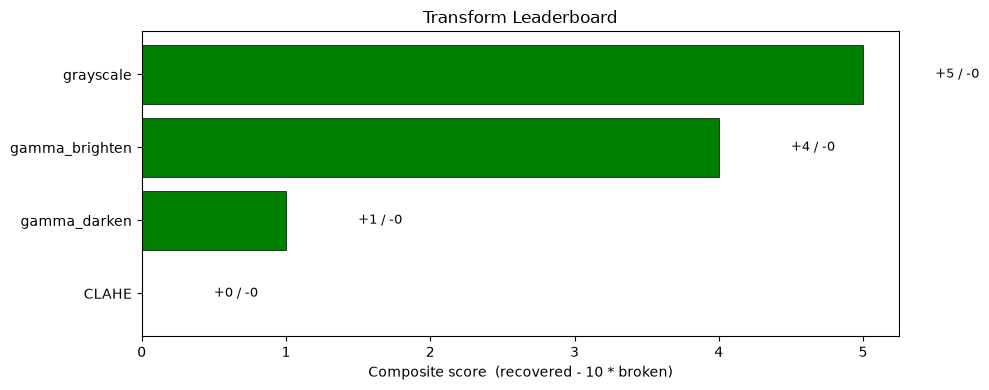

Chart saved to /mnt/hdd/projects/smile_detection/data/eda/transform_leaderboard.png

Top transform: grayscale — recovered 5 images with 0 broken on easy_control.
No transforms were disqualified.


In [33]:
hard_subs = ["hard_dark", "hard_bright", "hard_blur"]

summary_rows = []
for tx_name in transforms:
    tx_df = df_results[df_results["transform"] == tx_name]

    # Recovered: images in hard subsets that went from !=1 face to ==1 face
    hard_df = tx_df[tx_df["subset"].isin(hard_subs)]
    recovered = int(((hard_df["orig_n_faces"] != 1) & (hard_df["new_n_faces"] == 1)).sum())

    # Broken on easy_control: images that had 1 face and no longer do
    easy_df = tx_df[tx_df["subset"] == "easy_control"]
    broken = int(((easy_df["orig_n_faces"] == 1) & (easy_df["new_n_faces"] != 1)).sum())

    score = recovered - 10 * broken
    summary_rows.append({
        "transform": tx_name,
        "recovered": recovered,
        "broken": broken,
        "score": score,
    })

df_summary = pd.DataFrame(summary_rows).sort_values("score", ascending=False).reset_index(drop=True)
print("=== Transform leaderboard ===")
print(df_summary.to_string(index=False))

# --- Horizontal bar chart ---
colors = ["green" if b == 0 else "red" for b in df_summary["broken"]]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(
    df_summary["transform"],
    df_summary["score"],
    color=colors,
    edgecolor="black",
    linewidth=0.5,
)

for bar, row in zip(bars, df_summary.itertuples()):
    w = bar.get_width()
    ax.text(
        w + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"+{row.recovered} / -{row.broken}",
        va="center",
        fontsize=9,
    )

ax.set_xlabel("Composite score  (recovered - 10 * broken)")
ax.set_title("Transform Leaderboard")
ax.invert_yaxis()
plt.tight_layout()

chart_path = Path("..").resolve() / "data" / "eda" / "transform_leaderboard.png"
fig.savefig(chart_path, dpi=150)
plt.show()
print(f"Chart saved to {chart_path}")

# --- Verdicts ---
top = df_summary.iloc[0]
print(f"\nTop transform: {top['transform']} — recovered {top['recovered']} images "
      f"with {top['broken']} broken on easy_control.")

red = df_summary[df_summary["broken"] > 0]
if len(red) > 0:
    for _, r in red.iterrows():
        print(f"Disqualified: {r['transform']} — broke {r['broken']} previously-working detections "
              f"on easy_control.")
else:
    print("No transforms were disqualified.")

## 4. Clean Dataset


In [34]:
# Ensure the full df_det (all n_faces values) is on disk for later benchmarking
df_det.to_pickle(CACHE_DIR / "detections_raw.pkl")

# Clean dataset: single-face only
dataset_clean = (
    df_det[df_det["n_faces"] == 1]
    .drop(columns=["n_faces"])
    .reset_index(drop=True)
)
dataset_clean.to_pickle(CACHE_DIR / "dataset_clean.pkl")

print(f"dataset_clean images: {len(dataset_clean)}")
print(dataset_clean["label"].value_counts().rename({1: "smile", 0: "non_smile"}))
print(f"\n(df_det with all {len(df_det)} rows kept at data/cache/detections_raw.pkl)")

dataset_clean images: 3970
label
smile        2151
non_smile    1819
Name: count, dtype: int64

(df_det with all 3999 rows kept at data/cache/detections_raw.pkl)


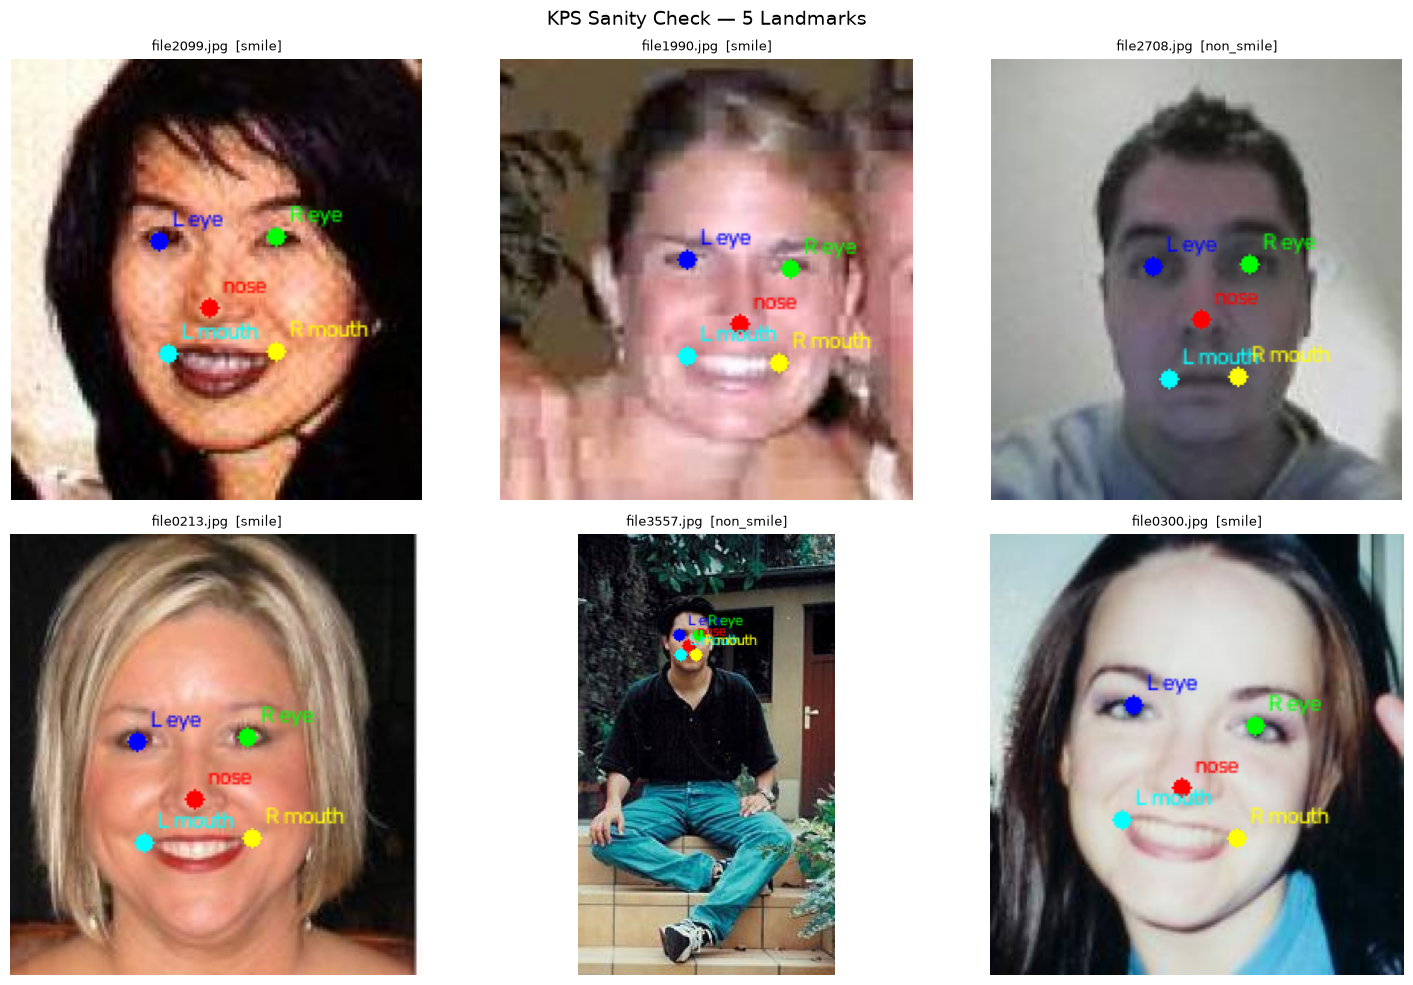

In [35]:
KPS_LABELS = ["L eye", "R eye", "nose", "L mouth", "R mouth"]
KPS_COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (0, 255, 255)]

sample = dataset_clean.sample(n=min(6, len(dataset_clean)), random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(sample.iterrows()):
    img = cv2.imread(row["filepath"])
    if img is None:
        axes[i].axis("off")
        continue

    kps = row["kps"]  # (5, 2) ndarray
    for j, (px, py) in enumerate(kps.astype(int)):
        cv2.circle(img, (px, py), 4, KPS_COLORS[j], -1)
        cv2.putText(img, KPS_LABELS[j], (px + 6, py - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.35, KPS_COLORS[j], 1, cv2.LINE_AA)

    axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    label_str = "smile" if row["label"] == 1 else "non_smile"
    axes[i].set_title(f"{row['filename']}  [{label_str}]", fontsize=9)
    axes[i].axis("off")

plt.suptitle("KPS Sanity Check — 5 Landmarks", fontsize=14)
plt.tight_layout()
plt.show()